# The seasonal with a law behind it ⛽
### Every spring, US gasoline gets pricier *by federal statute* — you can see it on the chart. So why can't you buy it?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Curve_prices_it%3F: Confirmed](https://img.shields.io/badge/Curve_prices_it%3F-Confirmed-8b949e?style=flat-square)

Most market seasonals are folklore — "sell in May," Santa rallies, harvest lows. This one is different: it has a **date written in the Federal Register**. By **May 1** every year, US refineries and terminals must ship **summer-blend gasoline** — a low-evaporation recipe (low "RVP") that can't use cheap butane and costs genuinely more to make. After **September 15**, the cheap winter blend becomes legal again.

So gasoline *should* get expensive relative to crude oil every spring and cheap again every fall — on schedule, by law. We check the tape. Spoiler: **the seasonal is enormous and lands exactly on the statute's dates**… and the second half of this story is the best free lesson in futures markets you'll get this year.

> 📓 **Plain-language layer.** Want the *t*-stats, the paired roll-gap test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **One honest caveat up front.** Our gasoline "price" series (`RB=F`) is a chain of futures contracts spliced together — it tracks the **pump-level price seasonal** perfectly, but nobody earns its roll-date jumps. That distinction turns out to be the entire story.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gasoline_rvp_seasonality import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    MRET = data.monthly_returns(PX)
    EX = st.excess_series(MRET)          # log(1+RB) - log(1+CL), spliced chains = spot proxy
else:
    PX = MRET = EX = None
print("real cache present:", HAVE_REAL,
      "| monthly excess obs:", (0 if EX is None else len(EX)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'asof': '2026-06-30', 'n_daily': 5412, 'n_excess': 257, 'win_mean': 3.77, 'rest_mean': -1.22, 'gap': 4.98, 'welch_years': 6.2, 'win_sum': 11.3, 't_win': 5.1, 'hit': 90.5, 'n_years': 21, 'welch_pooled': 4.23, 'n_pooled_w': 66, 'n_pooled_r': 191, 'months': [('Jan', 0.57, 0.31, 21), ('Feb', 1.34, 0.88, 22), ('Mar', 8.62, 5.34, 22), ('Apr', 1.72, 0.95, 22), ('May', -0.39, -0.26, 22), ('Jun', -1.54, -1.21, 22), ('Jul', 0.71, 0.59, 21), ('Aug', -0.5, -0.19, 21), ('Sep', -6.88, -3.12, 21), ('Oct', -2.82, -1.67, 21), ('Nov', 0.1, 0.09, 21), ('Dec', 0.79, 0.73, 21)], 'sep_mean': -6.88, 'sep_t': -3.12, 'sep_hit': 85.7, 'robust': [('Mar only', 8.78, 5.22, 5.61, 90), ('Mar-Apr', 10.14, 6.0, 6.8, 90), ('Feb-Apr', 11.3, 5.1, 6.2, 90), ('Feb-May', 10.91, 5.22, 6.38, 90)], 'halves': [('2005-2015', 9.6, 2.77, 11), ('2016-2025', 13.18, 4.81, 10)], 'roll_chain': 16.08, 'roll_holder': 5.68, 'roll_gap': -10.4, 'roll_t': -8.06, 'roll_neg': 100, 'roll_n': 18, 'sep_chain': -7.96, 'sep_holder': -1.58, 'sep_gap': 6.38, 'sep_gap_t': 4.95, 'inv_win_sum': -0.18, 'inv_t': -0.07, 'inv_hit': 47.1, 'inv_n': 17, 'inv_welch': -0.74, 'inv_sep': -0.02, 'inv_sep_t': -0.01, 'overlay': [(5.0, 9.45, 9.35, 1.48), (10.0, 9.45, 9.25, 1.46), (20.0, 9.45, 9.05, 1.43)], 'overlay_xcash': 8.91, 'overlay_xcash_t': 1.41, 'overlay_hit': 72.2, 'overlay_n': 18, 'syn_null': (-0.22, -0.24, 0.16, 0.03, 0.16), 'syn_plant': (4.61, 8.76, -2.76, -5.97, -42.35), 'fingerprint': 'ef905dc22f3c'}


real cache present: True | monthly excess obs: 257


## The answer first

| Question | Answer |
|---|---|
| Does gasoline really outrun crude every spring? | **Yes, massively.** Feb–Apr, gasoline beats crude by about **+11% per window**, positive in **19 of 21 years**. The odds of that being luck are microscopic. |
| Does it land on the legal dates? | **Exactly.** Of all 12 months, only **March** (run-up to the May-1 deadline) and **September** (switch-back) pass the strictest statistical bar — the two months the statute names. |
| Can you buy it? | **No.** The futures curve has read the law too: summer contracts already cost more all winter. Anyone actually *holding* gasoline futures pays the seasonal back at every roll — **-10.4% per spring**, in **18 out of 18 years**. |
| What's left after the roll? | **A coin flip.** The investable version earned **-0.18%** per window over 17 years — statistically indistinguishable from zero. |

> A seasonal can be 100% real at the pump and 0% available in your brokerage account. This is the cleanest example we know.

## 1 · The claim

> *"Summer gasoline is a legally different, more expensive product, and the switch happens on fixed dates (summer blend by May 1, winter blend legal again after Sept 15). So the gasoline-minus-crude spread must rally into spring and dump in September — every year, by law."*

The mechanism is real chemistry and real regulation: winter gasoline is padded with cheap butane, which evaporates too easily in summer heat (smog), so the EPA caps summer volatility (Reid Vapor Pressure). Refiners must drain the winter recipe, retool, and ship the pricier summer one — all against a **hard deadline**. Unlike "sell in May," this calendar has a *cause you can cite*: 40 CFR § 1090.215.

## 2 · So what?

If a price move is (a) big, (b) annual, and (c) scheduled by statute, it looks like the easiest trade in the world — just be long gasoline (against crude, to cancel the oil price itself) from February to April. If that worked, it would be free money printed by the Federal Register.

The catch every commodity trader learns once: you can't hold "gasoline." You hold **futures contracts**, and the sellers of those contracts have also read the law. The question isn't whether the seasonal exists — it's **who pockets it**.

## 3 · How would we even know?

We take **21 years** of daily prices (2005→2026): RBOB gasoline futures (`RB=F`), WTI crude (`CL=F`) as the control leg, and the gasoline ETF **UGA** as the "real holder." Then:

1. **Build the spread.** Each month, gasoline's return *minus* crude's return — so a general oil rally (or crash) cancels out and only gasoline-specific moves remain.
2. **Check the calendar.** Average that spread month by month across ~21 years. If the law matters, Feb–Apr should be positive and September negative — and *only* those.
3. **Follow the money.** Compare the spliced price chain (what the *pump* sees) with UGA (what a *holder* earns, paying every roll). The difference is who keeps the seasonal.

## 4 · The teardown — let's actually look

**The calendar, month by month.** Average gasoline-minus-crude monthly excess across all years. The statute predicts: up into spring, down in September.

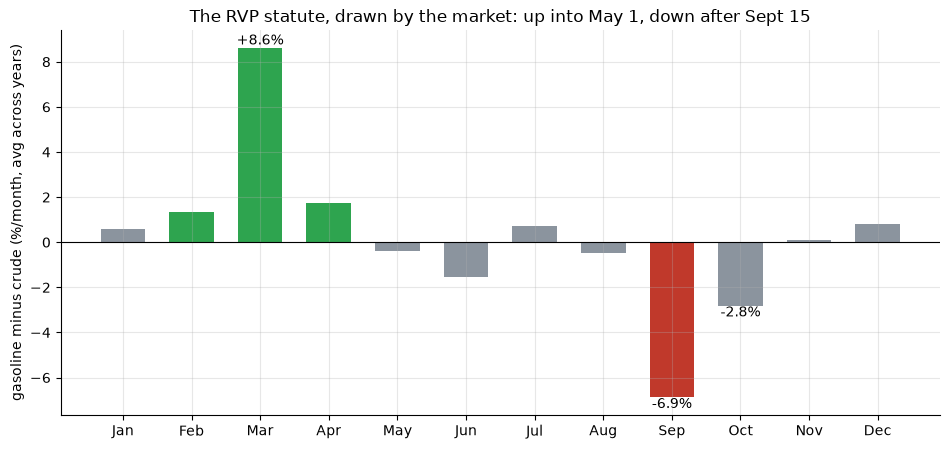

{'Jan': 0.57, 'Feb': 1.34, 'Mar': 8.62, 'Apr': 1.72, 'May': -0.39, 'Jun': -1.54, 'Jul': 0.71, 'Aug': -0.5, 'Sep': -6.88, 'Oct': -2.82, 'Nov': 0.1, 'Dec': 0.79}


In [2]:
if HAVE_REAL:
    mt = st.month_table(EX)
    vals = mt['mean_pct'].tolist()
else:
    vals = [m[1] for m in R['months']]
names = [m[0] for m in R['months']]
cols = [GREEN if n in ('Feb','Mar','Apr') else (RED if n=='Sep' else GREY) for n in names]
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.bar(names, vals, color=cols, width=.65)
ax.axhline(0, c='k', lw=.8)
for i, v in enumerate(vals):
    if abs(v) > 2.5: ax.annotate(f'{v:+.1f}%', (i, v), ha='center', va='bottom' if v>0 else 'top')
ax.set_ylabel('gasoline minus crude (%/month, avg across years)')
ax.set_title('The RVP statute, drawn by the market: up into May 1, down after Sept 15')
plt.tight_layout(); plt.show()
print({n: round(v,2) for n, v in zip(names, vals)})

That is a law showing up in prices. **March: +8.6%/month** on average (refiners scramble ahead of the May-1 deadline), **September: -6.9%/month** (cheap winter blend comes back). Every other month is noise around zero. The spring window (Feb–Apr) cumulates to **+11.3%** and was positive in **19 of 21 years**.

**Now the trap.** The green line below is the spliced price chain — the seasonal the pump sees. The grey line is **UGA**, a real fund that holds front-month gasoline futures and rolls them every month. Same windows, same years. Watch the gap.

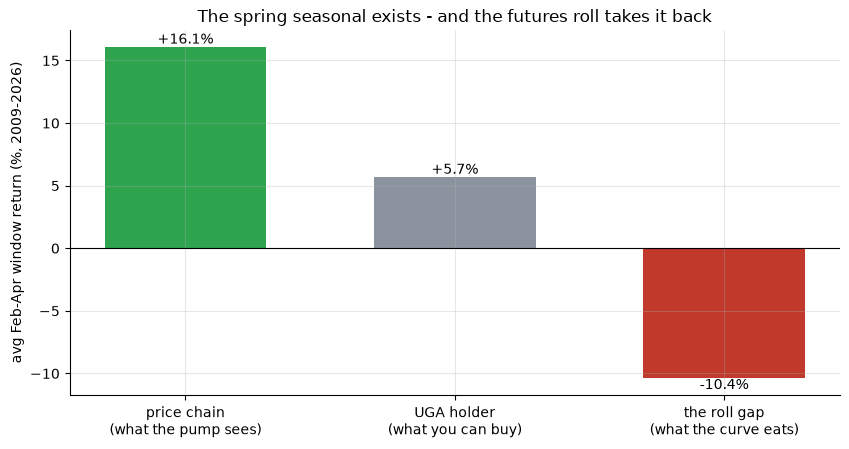

chain +16.08%  holder +5.68%  roll gap -10.40% per window


In [3]:
if HAVE_REAL:
    rg = st.roll_gap_stats(MRET, months=data.RUNUP_MONTHS)
    chain, holder, gap = rg['chain_pct'], rg['holder_pct'], rg['gap_pct']
else:
    chain, holder, gap = R['roll_chain'], R['roll_holder'], R['roll_gap']
fig, ax = plt.subplots(figsize=(8.6, 4.6))
bars = ax.bar(['price chain\n(what the pump sees)', 'UGA holder\n(what you can buy)',
               'the roll gap\n(what the curve eats)'], [chain, holder, gap],
              color=[GREEN, GREY, RED], width=.6)
ax.axhline(0, c='k', lw=.8)
for b, v in zip(bars, [chain, holder, gap]):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v), ha='center',
                va='bottom' if v>0 else 'top')
ax.set_ylabel('avg Feb-Apr window return (%, 2009-2026)')
ax.set_title('The spring seasonal exists - and the futures roll takes it back')
plt.tight_layout(); plt.show()
print(f'chain {chain:+.2f}%  holder {holder:+.2f}%  roll gap {gap:+.2f}% per window')

The price chain gains **+16.1%** per spring window; the actual holder keeps **+5.7%** (which is mostly just oil going up in spring). The missing **-10.4 points** is the **roll**: each month the fund must sell its expiring contract and buy the next one — and all winter long, the next (more-summer-y) contract *already costs more*, because the sellers know about May 1 too. That happened in **18 out of 18 years**. No exceptions, ever, in our sample.

And the mirror image: in September the holder *doesn't* lose the full crash — the curve already discounted it (holder -1.6% vs chain -8.0%). The curve gives back on the way down what it took on the way up. It prices the **statute**, both directions.

**So what's actually tradable?** Long UGA / short crude, February through April — the honest, buyable version of "own the spring gasoline seasonal."

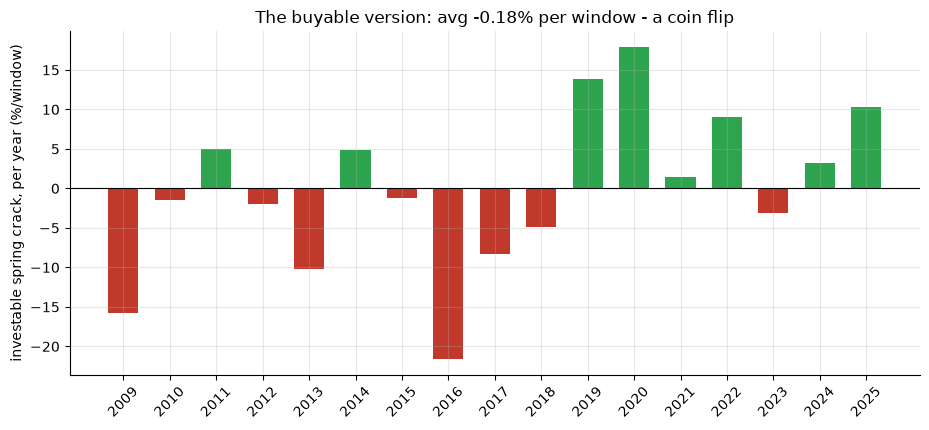

mean -0.18%/window, positive 47% of years


In [4]:
if HAVE_REAL:
    exi = st.excess_series(MRET, long='UGA', short='CL=F')
    pan = st.per_year_panel(exi, data.RUNUP_MONTHS)['win_sum'] * 100
    yrs, vals = pan.index.tolist(), pan.tolist()
else:
    yrs, vals = list(range(2010, 2027)), [R['inv_win_sum']] * 17
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.bar([str(y) for y in yrs], vals, color=[GREEN if v > 0 else RED for v in vals], width=.65)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('investable spring crack, per year (%/window)')
ax.set_title(f'The buyable version: avg {np.mean(vals):+.2f}% per window - a coin flip')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print(f'mean {np.mean(vals):+.2f}%/window, positive {100*np.mean([v>0 for v in vals]):.0f}% of years')

Average: **-0.18% per window**, positive **47%** of years — heads or tails. Twenty-one years of a thundering, statute-dated, 90%-hit-rate seasonal at the price level… and the version you can actually put in an account earns **nothing**. The sellers of May futures charged you the summer premium in January.

## 5 · The verdict

- **Signal — Real.** The RVP seasonal is one of the most statistically solid calendar effects on the desk's whole bench: **+11.3%** per Feb–Apr window (*t* ≈ 6.2), and only the statute's own two months survive the strictest test.
- **Tradability — Mirage.** The futures curve pre-prices the law. Holders pay the seasonal back at the rolls (-10.4%/window, 18/18 years); the investable crack earns -0.18%/window. There is nothing to buy.
- **"Does the curve already price it?" — Confirmed.** Both directions: it charges you the summer premium in spring rolls and refunds the winter discount in fall.

## 6 · Going further 🚪

- **This is THE lesson about commodity seasonals.** Spot seasonality ≠ futures returns. Any seasonal that everyone can date (harvests, heating oil in winter, natural gas shoulder months) lives in the *forward curve*, not in the holder's P&L. Before trading any commodity seasonal, ask: *is the curve shape already doing this?*
- **Contrast with a calendar that IS capturable:** [516-dividend-month-premium](../../516-dividend-month-premium/README.md) — also a schedule known in advance, but there no arbitrageur can fully pre-price it away.
- **Named siblings:** [226-crude-seasonality](../../226-crude-seasonality/README.md) (crude *outright* by month) and [306-crack-spread](../../306-crack-spread/README.md) (the crack *level* as a stock-timing signal). This study is the spread's *calendar*.

*Think you've found the commodity seasonal the curve missed? Show the holder-vs-chain gap first — then we'll talk.*